#Teleportação Quântica

**Teletransporte Quântico - Transferência Instantânea de Informação**


O teletransporte quântico é o processo pelo qual o estado quântico de um qubit pode ser transmitido de um local para outro, sem mover fisicamente o próprio qubit. Isso é alcançado usando os princípios de emaranhamento e superposição.
Aqui está um exemplo simples no Qiskit para demonstrar o teletransporte quântico.

In [ ]:
%%capture
!pip install qiskit[visualization]==1.2.2
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install matplotlib

In [ ]:
# Importe as bibliotecas necessárias para executar o projeto.
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import qiskit.quantum_info as qi

In [ ]:
# Crie um circuito quântico com 3 qubits e 3 bits clássicos
qc = QuantumCircuit(3, 3)

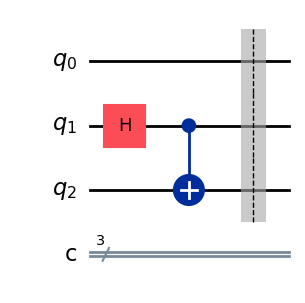

In [ ]:
# Etapa 1: Crie um par emaranhado entre o qubit 1 e o qubit 2
qc.h(1)
qc.cx(1, 2)
qc.barrier()
qc.draw('mpl')

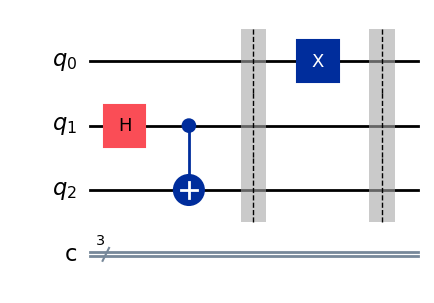

In [ ]:
# Etapa 2: Prepare o qubit 0 no estado a ser teletransportado
qc.x(0)
qc.barrier()
qc.draw('mpl')

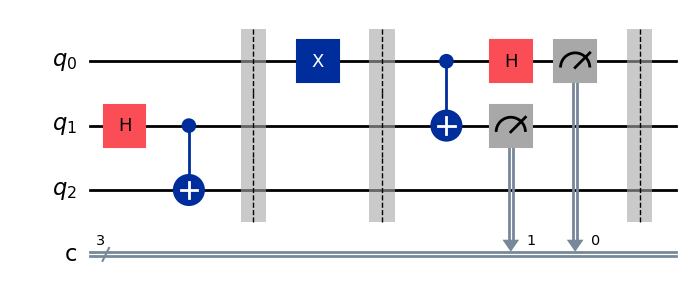

In [ ]:
# Etapa 3: Execute a medição de Bell no qubit 0 e qubit 1
# Aqui, Alice inicia o processo de envio do estado preparado.
qc.cx(0, 1)
qc.h(0)
qc.measure([0, 1], [0, 1])
qc.barrier()
qc.draw('mpl')

In [ ]:
# Use o simulador Qiskit Aer para executar o circuito
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()

Counts: {'011': 252, '000': 258, '010': 244, '001': 270}


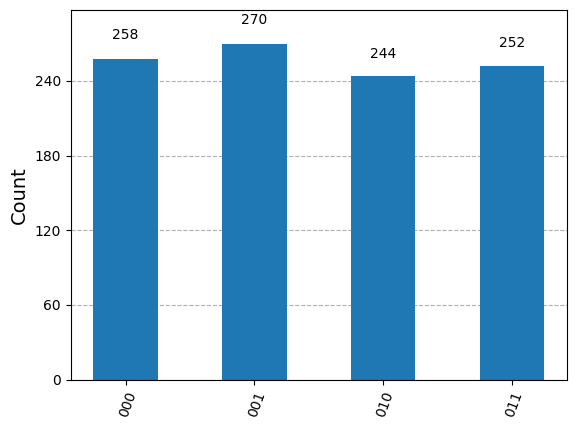

In [ ]:
# Obtenha a contagem dos resultados
counts = result.get_counts()
print("Counts:", counts)
# Visualize os resultados
plot_histogram(counts)

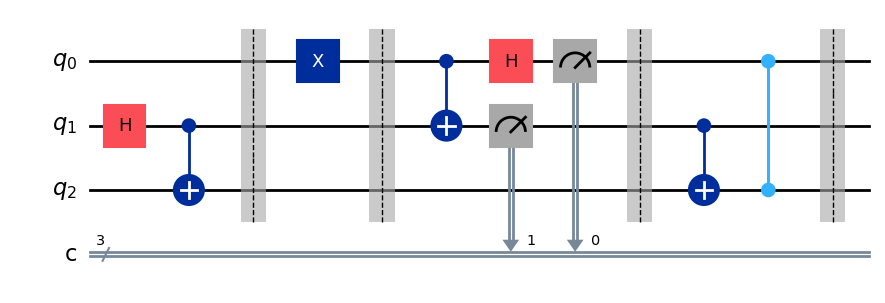

In [ ]:
# Etapa 4: Aplicar operações condicionais com base nos resultados da medição
qc.cx(1, 2)
qc.cz(0, 2)
qc.barrier()
qc.draw('mpl')

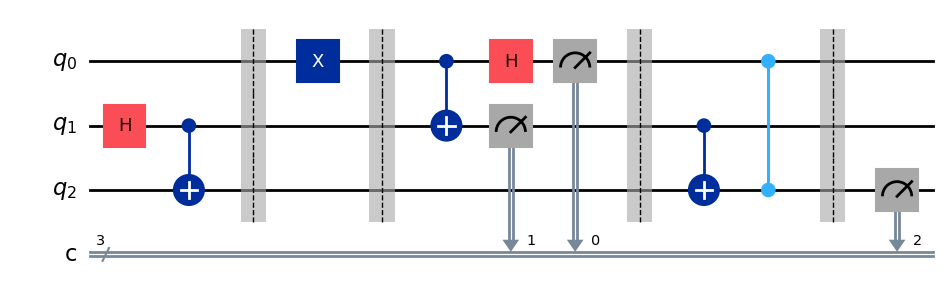

In [ ]:
# Etapa 5: Meça o qubit teletransportado
qc.measure(2, 2)
qc.draw('mpl')

In [ ]:
# Use o simulador Qiskit Aer para executar o circuito
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()

In [ ]:
# Obtenha a contagem dos resultados
counts = result.get_counts()
print("Counts:", counts)

Counts: {'100': 254, '110': 259, '111': 274, '101': 237}


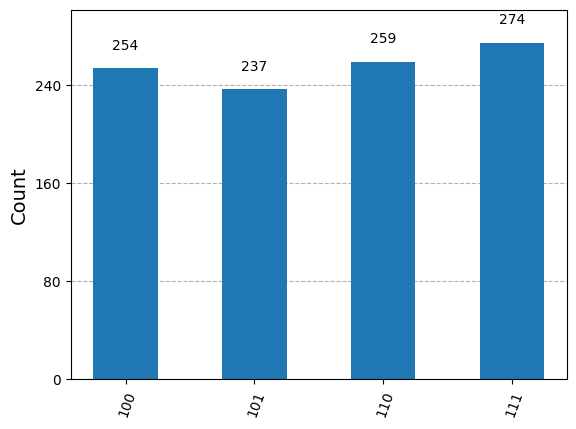

In [ ]:
# Visualize os resultados
plot_histogram(counts)

Neste exemplo, usamos três qubits. Os dois primeiros qubits são entrelaçados, criando um estado compartilhado. Então, preparamos o terceiro qubit (qubit 0) em um estado para ser teletransportado. Por meio de uma série de operações e medições, o estado do qubit 0 é transferido para o qubit 2.